TAREA: Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

In [53]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [54]:
# Lee la imagen (OpenCV la carga en BGR)
img = cv2.imread('mandril.jpg')

# Conversión a niveles de grises y detección de contornos con Canny
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
canny = cv2.Canny(gris, 100, 127)

In [55]:
# Suma por filas y división por el valor máximo del píxel (255)
# El resultado es la cantidad de píxeles blancos de cada fila
row_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
rows = row_counts[:, 0] / 255

# Valor máximo de píxeles blancos en una fila
max_row = np.max(rows)

# Filas cuyo valor es mayor o igual que el 90% del máximo
row_threshold = 0.90 * max_row
selected_rows = np.where(rows >= row_threshold)[0]

print(f"Valor máximo de píxeles blancos en una fila (max_row): {max_row}")
print(f"Número de filas que cumplen la condición: {len(selected_rows)}")
print(f"Posiciones de dichas filas: {selected_rows}")

Valor máximo de píxeles blancos en una fila (max_row): 223.0
Número de filas que cumplen la condición: 7
Posiciones de dichas filas: [  6  12  15  20  21  88 100]


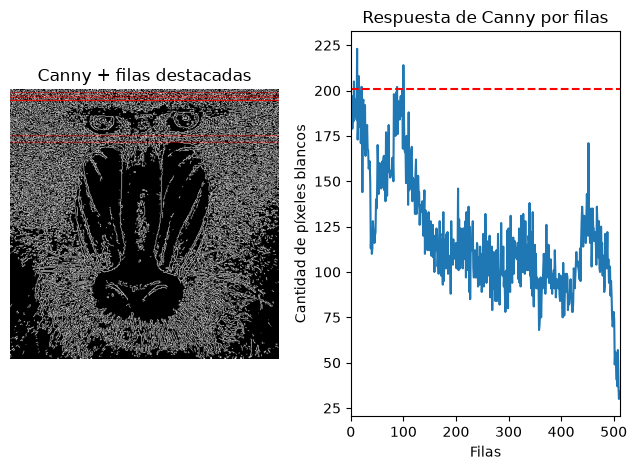

In [56]:
canny_color = cv2.cvtColor(canny, cv2.COLOR_GRAY2RGB)
for r in selected_rows:
    cv2.line(canny_color, (0, int(r)), (canny.shape[1] - 1, int(r)), (255, 0, 0), 1)

# --- Visualización con Matplotlib ---
plt.figure()

# Subgráfico 1: Imagen resultante
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny + filas destacadas")
plt.imshow(canny_color)

# Subgráfico 2: Histograma de filas
plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny por filas")
plt.xlabel("Filas")
plt.ylabel("Cantidad de píxeles blancos")
plt.plot(rows)
plt.axhline(row_threshold, color='r', linestyle='--')      # línea del 90% del máximo
plt.xlim([0, canny.shape[0]])

plt.tight_layout()

plt.show()

TAREA: Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobe tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

In [57]:
img = cv2.imread('mandril.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

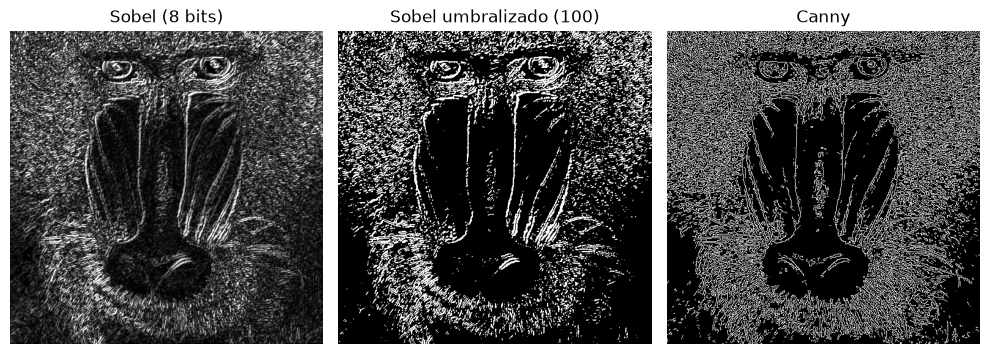

In [58]:
# Suavizado y derivadas en x e y
gaussian_gris = cv2.GaussianBlur(gris, (3, 3), 0)
sobelx = cv2.Sobel(gaussian_gris, cv2.CV_64F, 1, 0)
sobely = cv2.Sobel(gaussian_gris, cv2.CV_64F, 0, 1)
sobel = cv2.add(sobelx, sobely)

# Conversión a 8 bits (valor absoluto y escalado a [0, 255])
sobel8 = cv2.convertScaleAbs(sobel)

# Umbralizado de Sobel (prueba otros valores)
umbral_sobel = 100
_, sobel_umbral = cv2.threshold(sobel8, umbral_sobel, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1); plt.axis("off"); plt.title("Sobel (8 bits)"); plt.imshow(sobel8, cmap='gray')
plt.subplot(1, 3, 2); plt.axis("off"); plt.title(f"Sobel umbralizado ({umbral_sobel})"); plt.imshow(sobel_umbral, cmap='gray')
plt.subplot(1, 3, 3); plt.axis("off"); plt.title("Canny"); plt.imshow(canny, cmap='gray')
plt.tight_layout()
plt.show()

In [59]:
# Conteo por filas (Sobel)
row_counts_s = cv2.reduce(sobel_umbral, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
rows_s = row_counts_s[:, 0] / 255
max_row_s = np.max(rows_s)
sel_rows_s = np.where(rows_s >= 0.90 * max_row_s)[0]

# Conteo por columnas (Sobel) - Nota el '0' en cv2.reduce
col_counts_s = cv2.reduce(sobel_umbral, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
cols_s = col_counts_s[0, :] / 255
max_col_s = np.max(cols_s)
sel_cols_s = np.where(cols_s >= 0.90 * max_col_s)[0]

img_sobel_draw = img_rgb.copy()
for r in sel_rows_s:
    cv2.line(img_sobel_draw, (0, int(r)), (img_sobel_draw.shape[1] - 1, int(r)), (255, 0, 0), 1) # Rojo
for c in sel_cols_s:
    cv2.line(img_sobel_draw, (int(c), 0), (int(c), img_sobel_draw.shape[0] - 1), (0, 255, 0), 1) # Verde

In [60]:
canny = cv2.Canny(gris, 100, 200)

# Conteo por filas (Canny)
row_counts_c = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
rows_c = row_counts_c[:, 0] / 255
max_rows_c = np.max(rows_c)
sel_rows_c = np.where(rows_c >= 0.90 * max_rows_c)[0]

# Conteo por columnas (Canny)
col_counts_c = cv2.reduce(canny, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
cols_c = col_counts_c[0, :] / 255
max_cols_c = np.max(cols_c)
sel_cols_c = np.where(cols_c >= 0.90 * max_cols_c)[0]

# Dibujar sobre otra copia de la imagen original
img_canny_draw = img_rgb.copy()
for r in sel_rows_c:
    cv2.line(img_canny_draw, (0, int(r)), (img_canny_draw.shape[1] - 1, int(r)), (255, 0, 0), 1)
for c in sel_cols_c:
    cv2.line(img_canny_draw, (int(c), 0), (int(c), img_canny_draw.shape[0] - 1), (0, 255, 0), 1)

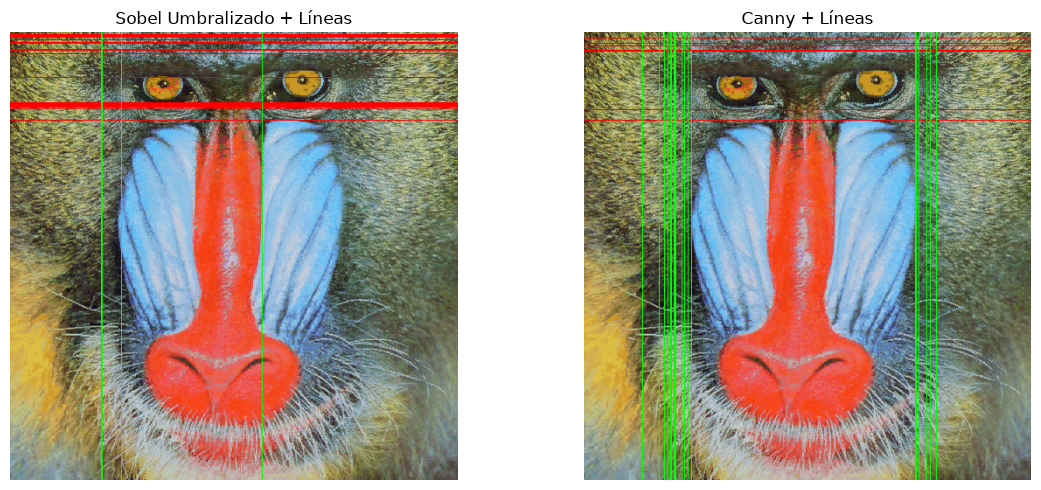

In [61]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Sobel Umbralizado + Líneas")
plt.axis("off")
plt.imshow(img_sobel_draw)

plt.subplot(1, 2, 2)
plt.title("Canny + Líneas")
plt.axis("off")
plt.imshow(img_canny_draw)

plt.tight_layout()
plt.show()

Al comparar los resultados se observa que cada algoritmo trata los detalles de la imagen de forma distinta.

En el caso de Sobel (izquierda), aparece un bloque grueso de líneas rojas horizontales en la parte superior de la cabeza. Esto se debe a que Sobel es muy sensible a texturas intensas, como el pelo del mandril. Genera bordes anchos y satura esa zona de píxeles blancos. Además, apenas aparecen líneas verdes verticales. El ruido del pelaje hace que alguna columna concentre un número muy elevado de píxeles, lo que eleva considerablemente el umbral del 90 % y deja fuera el resto de estructuras verticales de la cara.

En el caso de Canny (derecha), el resultado está más estructurado. Las líneas rojas de la zona superior son más finas y están más separadas, sin formar un bloque saturado, ya que Canny atenúa el ruido y reduce los bordes a un píxel de grosor. Esto se aprecia especialmente en las líneas verdes verticales, que se agrupan y delimitan con claridad los laterales de la nariz y el contorno de la cara. Al tratarse de un método más preciso, el conteo ignora en gran medida el ruido de la textura y destaca la geometría real del mandril.

En conclusión, Sobel tiende a saturarse en presencia de mucha textura, mientras que Canny ofrece un resultado más limpio. Esto permite que el conteo por filas y columnas enmarque las formas relevantes del animal en lugar de verse afectado por el ruido del pelaje.

TAREA: Tras ver los vídeos My little piece of privacy, Messa di voce y Virtual air guitar proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.

In [66]:
import random
import time

# ==========================CONFIGURACIÓN==========================

# Camara a usar
CAMERA = 0
# Vidas totales
lives = 3
# Tiempo inicial para romper cada cristal
crystal_uptime = 2.5
# Tiempo mínimo
min_uptime = 0.7
# Cada cristal roto reduce el tiempo
time_reduction = 0.05
# Movimiento necesario dentro del cristal
hit_threshold = 350
# Tiempo desde que aparece el cristal hasta poder romperlo
spawn_shield_time = 0.25
# Tamaño del cristal
crystal_radius = 30


# ==========================FUNCIONES==========================

def generate_crystal(width, height):
    """
    Define las coordenadas donde saldrá el siguiente cristal de forma aleatoria,
    evitando el centro de la pantalla.
    """

    margin = 80

    side = random.choice(["left", "right"])

    if side == "left":
        x = random.randint(margin, int(width * 0.27))

    else:
        x = random.randint(int(width * 0.73), width - margin)

    y = random.randint(margin + 20, height - margin)

    crystal_type = random.choices(["blue", "red"], weights=[75, 25],k=1)[0]

    return x, y, crystal_type


def draw_crystal(frame, x, y, radius, crystal_type):
    """
    Dibuja un cristal con forma de rombo en unas coordenadas dadas.
    """

    points = np.array([ [x, y - radius], [x + radius, y], [x, y + radius], [x - radius, y] ], np.int32)
    points = points.reshape((-1, 1, 2))

    if crystal_type == "blue":
        color = (255, 220, 80)

    else:
        color = (0, 0, 255)

    cv2.fillPoly( frame, [points], color)
    cv2.polylines( frame, [points], True, (255, 255, 255), 3 )


def draw_interface(frame, current_lives, score):
    """
    Muestra los valores de vidas restantes y cristales totales rotos
    """

    cv2.putText(frame, f"VIDAS: {current_lives}", (20, 40), cv2.FONT_HERSHEY_SIMPLEX,1, (25, 50, 255), 2)
    cv2.putText(frame, f"CRISTALES: {score}", (425, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 220, 80), 2)



# ==========================WEBCAM==========================

cap = cv2.VideoCapture(CAMERA)

if not cap.isOpened():

    print("No se ha podido abrir la webcam.")

else:

    # ==========================VARIABLES DEL JUEGO==========================

    game_state = "PLAYING"
    current_lives = lives
    score = 0
    crystal_x = None
    crystal_y = None
    crystal_type = None
    crystal_spawn_time = 0
    current_crystal_uptime = crystal_uptime
    previous_frame = None
   
    # ==========================BUCLE PRINCIPAL==========================

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        # Efecto espejo
        frame = cv2.flip(frame, 1)
        height, width = frame.shape[:2]


        # ==========================DETECCIÓN DE MOVIMIENTO==========================

        gray_frame = cv2.cvtColor( frame, cv2.COLOR_BGR2GRAY )
        gray_frame = cv2.GaussianBlur( gray_frame, (7, 7), 0)

        if previous_frame is None:
            previous_frame = gray_frame.copy()
            crystal_x, crystal_y, crystal_type = generate_crystal(width, height)
            crystal_spawn_time = time.time()

        difference = cv2.absdiff(previous_frame, gray_frame)
        _, movement = cv2.threshold(difference,25,255,cv2.THRESH_BINARY)
        kernel = np.ones((5, 5),np.uint8)
        movement = cv2.morphologyEx(movement,cv2.MORPH_OPEN,kernel)
        movement = cv2.dilate(movement,kernel,iterations=2)
        previous_frame = gray_frame.copy()


        # ==========================JUGANDO==========================

        if game_state == "PLAYING":

            # Interfaz
            draw_interface(frame,current_lives,score)
            crystal_elapsed_time = (time.time() - crystal_spawn_time)
            crystal_time_left = (current_crystal_uptime- crystal_elapsed_time)

            # Dibujamos cristal
            draw_crystal(frame,crystal_x,crystal_y,crystal_radius, crystal_type)

            # tiempo restante del cristal
            time_percentage = max(crystal_time_left/ current_crystal_uptime,0)
            time_bar_width = 100
            time_bar_x = (crystal_x- time_bar_width // 2)
            time_bar_y = (crystal_y+ crystal_radius+ 15)
            cv2.rectangle(frame,(time_bar_x,time_bar_y),(time_bar_x + time_bar_width,time_bar_y + 10),(255, 255, 255),2)
            cv2.rectangle(frame,(time_bar_x,time_bar_y),(time_bar_x+ int(time_bar_width* time_percentage),time_bar_y + 10),(255, 255, 255),-1)

            # Zona del cristal
            x1 = max(crystal_x - crystal_radius,0)
            x2 = min(crystal_x + crystal_radius,width)
            y1 = max(crystal_y - crystal_radius,0)
            y2 = min(crystal_y + crystal_radius,height)
            crystal_zone = movement[y1:y2,x1:x2]
            crystal_movement = cv2.countNonZero(crystal_zone)

            # Golpeo de cristal
            if (crystal_elapsed_time > spawn_shield_time and crystal_movement > hit_threshold):
                if  crystal_type == "blue":

                    score += 1

                    # Reducir tiempo para romper el cristal
                    current_crystal_uptime = max(min_uptime,crystal_uptime - score * time_reduction)
                
                else:
                    current_lives -= 1

                    if current_lives <= 0:
                        game_state = "GAME_OVER"

                if game_state == "PLAYING":

                    # Nuevo cristal
                    crystal_x, crystal_y, crystal_type = generate_crystal(width, height)
                    crystal_spawn_time = time.time()


            # Cristal no golpeado
            elif crystal_time_left <= 0:
                if crystal_type == "blue":

                    current_lives -= 1

                    if current_lives <= 0:

                        game_state = "GAME_OVER"

                if game_state == "PLAYING":

                    crystal_x, crystal_y, crystal_type = generate_crystal(width,height)
                    crystal_spawn_time = time.time()

        # ==========================GAME OVER==========================

        elif game_state == "GAME_OVER":

            text = "GAME OVER"
            text_size = cv2.getTextSize(text,cv2.FONT_HERSHEY_SIMPLEX,2,5)[0]
            cv2.putText(frame,text,(int(width / 2- text_size[0] / 2),int(height / 2 - 50)),cv2.FONT_HERSHEY_SIMPLEX,2,(0, 0, 255),5)
            cv2.putText(frame,f"Cristales rotos: {score}",(int(width / 2 - 170),int(height / 2 + 20)),cv2.FONT_HERSHEY_SIMPLEX,0.9,(255, 255, 255),2)
            cv2.putText(frame,"Pulsa R para reiniciar",(int(width / 2 - 160),int(height / 2 + 70)),cv2.FONT_HERSHEY_SIMPLEX,0.7,(255, 255, 255),2)


        # ==========================MOSTRAR VENTANA==========================

        cv2.imshow("Rompe Cristales",frame)
        key = cv2.waitKey(1) & 0xFF

        # ESC para salir
        if key == 27:
            break

        # R para reiniciar
        if key == ord("r"):

            current_lives = lives
            score = 0
            current_crystal_uptime = crystal_uptime
            crystal_x, crystal_y, crystal_type = generate_crystal(width,height)
            crystal_spawn_time = time.time()
            game_state = "PLAYING"

    cap.release()
    cv2.destroyAllWindows()